In [1]:
import sys, os

proj_dir = "/workspace/Coprocessor_for_Llama"
parent_of_proj = os.path.dirname(proj_dir)   # -> "/workspace"

if parent_of_proj not in sys.path:
    sys.path.insert(0, parent_of_proj)


In [2]:
from pathlib import Path
import optuna
from optuna.trial import TrialState
import pandas as pd
import matplotlib.pyplot as plt
from Coprocessor_for_Llama.co_design.interface.utils import load_toml_config
from Coprocessor_for_Llama.co_design.search.utils import post_search

# --- config (m sure these are strings) ---
# STUDY_NAME = "Random_42_1b"
# STUDY_NAME = "botorch_sequential"  
STUDY_NAME = "botorch_42_1b"              
DB_PATH = Path.cwd().parent / f"{STUDY_NAME}.db" 
STORAGE_URL = f"sqlite:///{DB_PATH.resolve()}" 

print(STUDY_NAME, type(STUDY_NAME))
print(STORAGE_URL, type(STORAGE_URL))

# --- load study ---
study = optuna.load_study(study_name=str(STUDY_NAME), storage=str(STORAGE_URL))


tunables = load_toml_config(file_path = "/workspace/Coprocessor_for_Llama/src/definitions/config.toml", mode="tunable_range")
print(f"[INFO] Loaded {len(tunables)} tunable parameters.")



rows = []
for t in study.get_trials(deepcopy=False, states=(TrialState.COMPLETE,)):
    # values: tuple/list of objectives (e.g., [acc, lat, area] if that's how you returned them)
    vals = list(t.values) if t.values is not None else [None, None, None]
    # user attrs (raw metrics you stored)
    acc_raw = t.user_attrs.get("accuracy_raw")
    lat_raw = t.user_attrs.get("latency_raw")
    area_raw = t.user_attrs.get("area_raw")
    rows.append({
        "trial_number": t.number,
        "acc": vals[0] if len(vals) > 0 else None,
        "lat": vals[1] if len(vals) > 1 else None,
        "area": vals[2] if len(vals) > 2 else None,
        "acc_raw": acc_raw,
        "lat_raw": lat_raw,
        "area_raw": area_raw,
        **{f"param_{k}": v for k, v in t.params.items()},
    })

df = pd.DataFrame(rows).sort_values("trial_number").reset_index(drop=True)
# display(df.head(10))


/opt/conda/envs/acc-sim/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


botorch_42_1b <class 'str'>
sqlite:////workspace/Coprocessor_for_Llama/co_design/botorch_42_1b.db <class 'str'>
[INFO] Loaded 10 tunable parameters.


In [3]:
post_search(study_name=STUDY_NAME, storage=STORAGE_URL, normalize=True)


[INFO] Number of Pareto-optimal trials: 1
[INFO] Number of successfully completed (non-pruned) trials: 10

[Trial 0]
  Normalized Objectives: accuracy=1.0000, latency=-0.8186, area=-1.0000
  Denormalized Objectives: accuracy=20.00, latency=0.2429, area=120246991.00
  Parameters:
    BLEN: 32
    MLEN: 128
    VLEN: 16
    HBM_M_Prefetch_Amount: 8
    HBM_V_Prefetch_Amount: 256
    HBM_V_Writeback_Amount: 16
    ACT_ELEMENT_WIDTH: MXFP_E1M2
    KV_ELEMENT_WIDTH: MXFP_E4M3
    FP_SETTING: FP_E8M5
    INT_DATA_WIDTH: 64


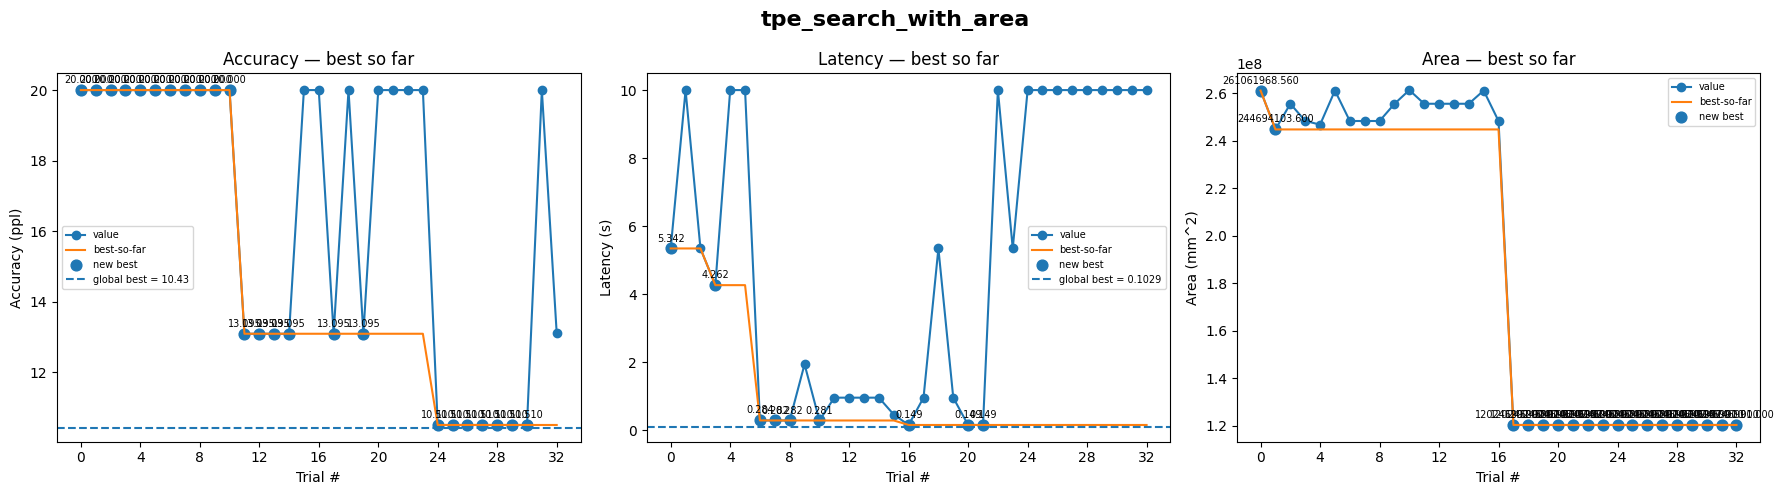

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def log_scale(val):
    """Log scaling function: log10(1+x)."""
    return np.log1p(val) / np.log(10)

def denormalize_objective(val, min_val, max_val, sym=True, use_log=True):
    """
    Denormalize an objective value from normalized space back to original scale.
    Inverse of normalize_objective (approximate if log scaling applied).
    """
    if use_log:
        min_val = log_scale(min_val)
        max_val = log_scale(max_val)

    if not sym:
        raw = val * (max_val - min_val + 1e-8) + min_val
    else:
        raw = (val + 1) / 2 * (max_val - min_val + 1e-8) + min_val

    if use_log:
        # Inverse of log_scale: x = 10^raw - 1
        return np.power(10, raw) - 1
    return raw


def _is_new_best(y, mode):
    y = y.astype(float)
    if mode == "max":
        best = np.maximum.accumulate(y)
    else:
        best = np.minimum.accumulate(y)
    return y == best, best

def _plot_best_so_far(ax, df, col, mode, ylabel, title,
                      min_val=None, max_val=None, sym=True,
                      hline=None, ylim=None):
    if col not in df:
        return

    x = np.arange(len(df["trial_number"]))
    # x = len(df["trial_number"]).to_numpy()
    y_norm = df[col].astype(float).to_numpy()

    # Denormalize if bounds provided
    if min_val is not None and max_val is not None:
        y = np.array([denormalize_objective(v, min_val, max_val, sym) for v in y_norm])
    else:
        y = y_norm

    is_new, best_so_far = _is_new_best(y, mode)

    ax.plot(x, y, marker="o", label="value")
    ax.plot(x, best_so_far, label="best-so-far")
    ax.scatter(x[is_new], y[is_new], s=60, label="new best")

    # Horizontal reference line for the global best (if provided)
    if hline is not None:
        ax.axhline(hline, linestyle="--", label=f"global best = {hline:.4g}")

    # Annotate new best points
    for xi, yi in zip(x[is_new], y[is_new]):
        ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points", xytext=(0, 5),
                    ha="center", fontsize=7)

    ax.set_xlabel("Trial #")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # 👈 force integer ticks
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=7)


# ==== Parameters ====
ACC_MIN, ACC_MAX = 9, 20
LAT_MIN, LAT_MAX = 0, 10
AREA_MIN, AREA_MAX = 120246991, 500000000

ACC_BEST = 10.425
LAT_BEST = 0.102908814

# ==== Single Figure with 3 Subplots ====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

_plot_best_so_far(
    axes[0], df, "acc", mode="min",
    ylabel="Accuracy (ppl)",
    title="Accuracy — best so far",
    min_val=ACC_MIN, max_val=ACC_MAX, sym=True,
    hline=ACC_BEST
)

_plot_best_so_far(
    axes[1], df, "lat", mode="min",
    ylabel="Latency (s)",
    title="Latency — best so far",
    min_val=LAT_MIN, max_val=LAT_MAX, sym=True,
    hline=LAT_BEST
)

_plot_best_so_far(
    axes[2], df, "area", mode="min",
    ylabel="Area (mm^2)",
    title="Area — best so far",
    min_val=AREA_MIN, max_val=AREA_MAX, sym=True
)
fig.suptitle(STUDY_NAME, fontsize=16, fontweight="bold")


plt.tight_layout()
plt.show()


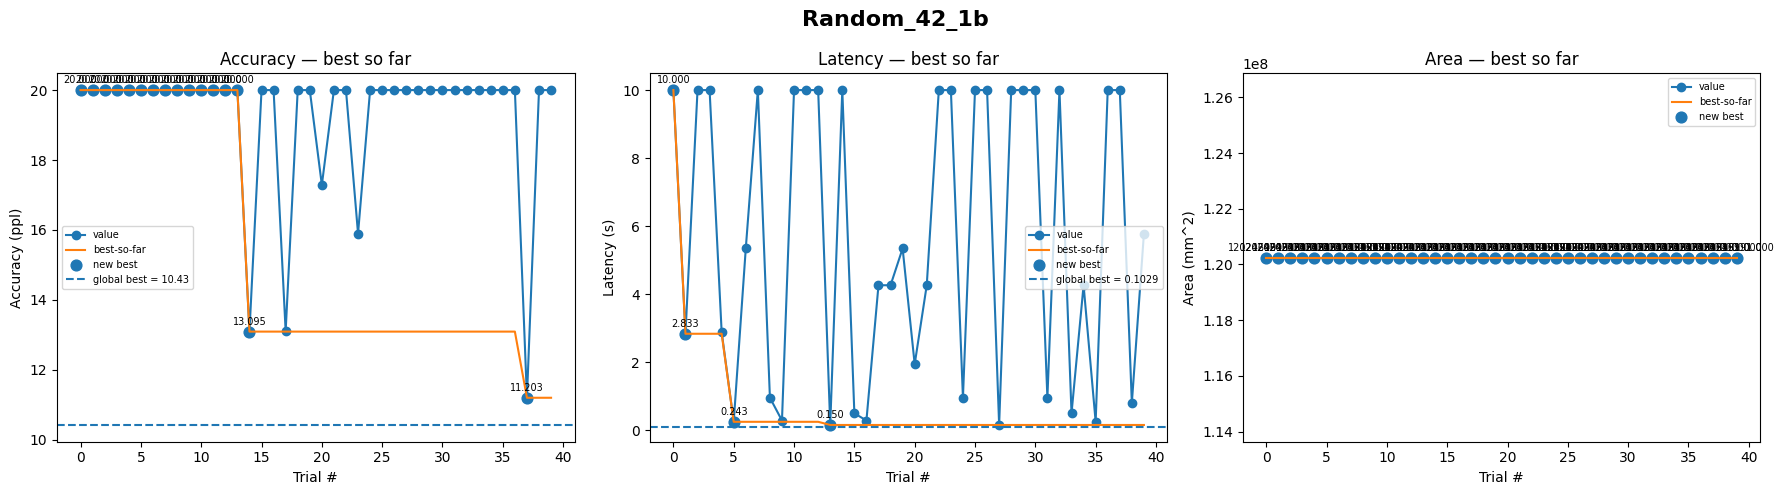

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def log_scale(val):
    """Log scaling function: log10(1+x)."""
    return np.log1p(val) / np.log(10)

def denormalize_objective(val, min_val, max_val, sym=True, use_log=True):
    """
    Denormalize an objective value from normalized space back to original scale.
    Inverse of normalize_objective (approximate if log scaling applied).
    """
    if use_log:
        min_val = log_scale(min_val)
        max_val = log_scale(max_val)

    if not sym:
        raw = val * (max_val - min_val + 1e-8) + min_val
    else:
        raw = (val + 1) / 2 * (max_val - min_val + 1e-8) + min_val

    if use_log:
        # Inverse of log_scale: x = 10^raw - 1
        return np.power(10, raw) - 1
    return raw


def _is_new_best(y, mode):
    y = y.astype(float)
    if mode == "max":
        best = np.maximum.accumulate(y)
    else:
        best = np.minimum.accumulate(y)
    return y == best, best

def _plot_best_so_far(ax, df, col, mode, ylabel, title,
                      min_val=None, max_val=None, sym=True,
                      hline=None, ylim=None):
    if col not in df:
        return

    x = np.arange(len(df["trial_number"]))
    # x = len(df["trial_number"]).to_numpy()
    y_norm = df[col].astype(float).to_numpy()

    # Denormalize if bounds provided
    if min_val is not None and max_val is not None:
        y = np.array([denormalize_objective(v, min_val, max_val, sym) for v in y_norm])
    else:
        y = y_norm

    is_new, best_so_far = _is_new_best(y, mode)

    ax.plot(x, y, marker="o", label="value")
    ax.plot(x, best_so_far, label="best-so-far")
    ax.scatter(x[is_new], y[is_new], s=60, label="new best")

    # Horizontal reference line for the global best (if provided)
    if hline is not None:
        ax.axhline(hline, linestyle="--", label=f"global best = {hline:.4g}")

    # Annotate new best points
    for xi, yi in zip(x[is_new], y[is_new]):
        ax.annotate(f"{yi:.3f}", (xi, yi), textcoords="offset points", xytext=(0, 5),
                    ha="center", fontsize=7)

    ax.set_xlabel("Trial #")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))  # 👈 force integer ticks
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=7)


# ==== Parameters ====
ACC_MIN, ACC_MAX = 9, 20
LAT_MIN, LAT_MAX = 0, 10
AREA_MIN, AREA_MAX = 120246991, 500000000

ACC_BEST = 10.425
LAT_BEST = 0.102908814

# ==== Single Figure with 3 Subplots ====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

_plot_best_so_far(
    axes[0], df[:40], "acc", mode="min",
    ylabel="Accuracy (ppl)",
    title="Accuracy — best so far",
    min_val=ACC_MIN, max_val=ACC_MAX, sym=True,
    hline=ACC_BEST
)

_plot_best_so_far(
    axes[1], df[:40], "lat", mode="min",
    ylabel="Latency (s)",
    title="Latency — best so far",
    min_val=LAT_MIN, max_val=LAT_MAX, sym=True,
    hline=LAT_BEST
)

_plot_best_so_far(
    axes[2], df[:40], "area", mode="min",
    ylabel="Area (mm^2)",
    title="Area — best so far",
    min_val=AREA_MIN, max_val=AREA_MAX, sym=True
)
fig.suptitle(STUDY_NAME, fontsize=16, fontweight="bold")


plt.tight_layout()
plt.show()


SyntaxError: invalid decimal literal (2412219305.py, line 60)

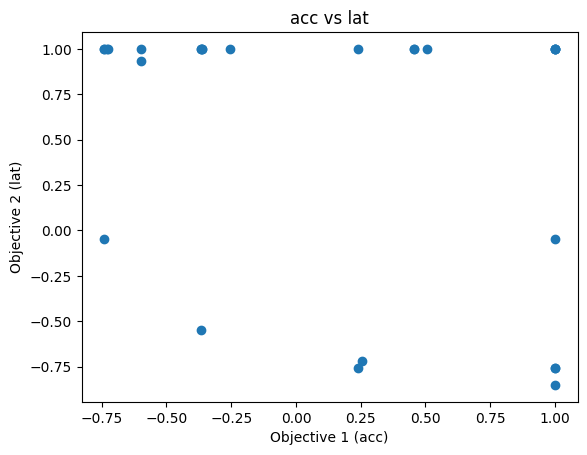

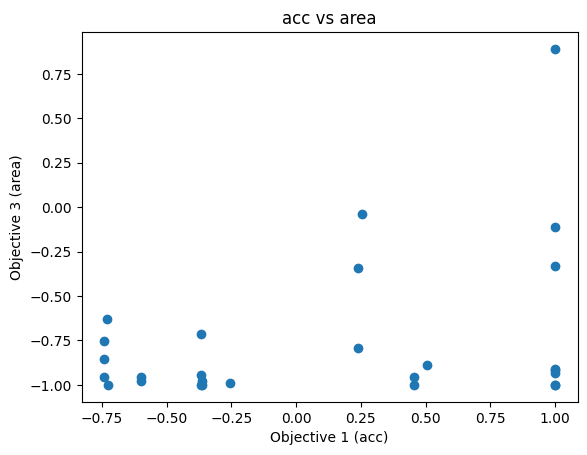

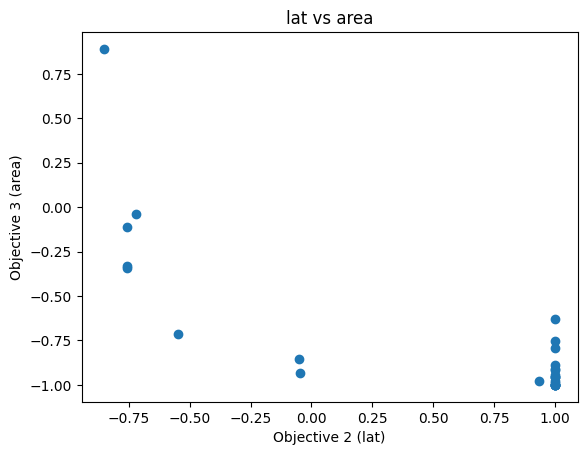

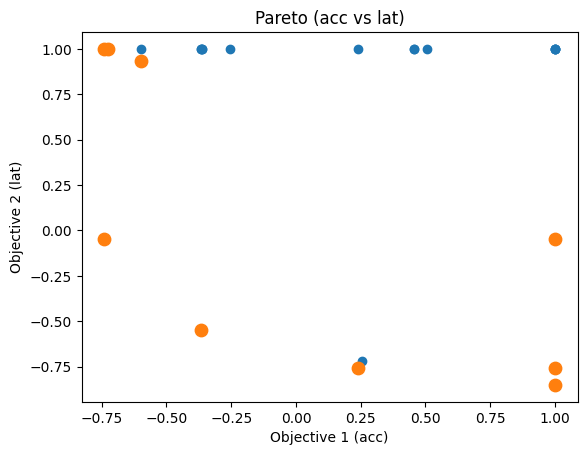

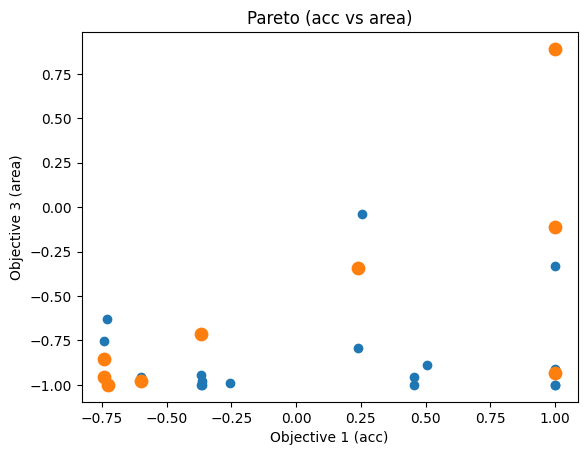

In [131]:

# 2) Raw metrics vs trial number (if you stored them)
if df["acc_raw"].notna().any():
    plt.figure()
    plt.plot(df["trial_number"], df["acc_raw"], marker="o")
    plt.xlabel("Trial #")
    plt.ylabel("accuracy_raw")
    plt.title("Raw Accuracy vs Trial")
    plt.show()

if df["lat_raw"].notna().any():
    plt.figure()
    plt.plot(df["trial_number"], df["lat_raw"], marker="o")
    plt.xlabel("Trial #")
    plt.ylabel("latency_raw")
    plt.title("Raw Latency vs Trial")
    plt.show()

if df["area_raw"].notna().any():
    plt.figure()
    plt.plot(df["trial_number"], df["area_raw"], marker="o")
    plt.xlabel("Trial #")
    plt.ylabel("area_raw")
    plt.title("Raw Area vs Trial")
    plt.show()

# 3) Scatter plots between objectives
if {"acc","lat"}.issubset(df.columns):
    plt.figure()
    plt.scatter(df["acc"], df["lat"])
    plt.xlabel("Objective 1 (acc)")
    plt.ylabel("Objective 2 (lat)")
    plt.title("acc vs lat")
    plt.show()

if {"acc","area"}.issubset(df.columns):
    plt.figure()
    plt.scatter(df["acc"], df["area"])
    plt.xlabel("Objective 1 (acc)")
    plt.ylabel("Objective 3 (area)")
    plt.title("acc vs area")
    plt.show()

if {"lat","area"}.issubset(df.columns):
    plt.figure()
    plt.scatter(df["lat"], df["area"])
    plt.xlabel("Objective 2 (lat)")
    plt.ylabel("Objective 3 (area)")
    plt.title("lat vs area")
    plt.show()

# 4) Pareto front highlighting (for multi-objective)
pareto = study.best_trials  # non-dominated set
if pareto:
    pareto_df = pd.DataFrame(
        [{"trial_number": t.number, "acc": t.values[0], "lat": t.values[1], "area": t.values[2]} for t in pareto]
    )

    # Example 2D projection: acc vs lat, mark Pareto in larger markers
    if {"acc","lat"}.issubset(df.columns):
        plt.figure()
        plt.scatter(df["acc"], df["lat"])
        plt.scatter(pareto_df["acc"], pareto_df["lat"], marker="o", s=80)
        plt.xlabel("Objective 1 (acc)")
        plt.ylabel("Objective 2 (lat)")
        plt.title("Pareto (acc vs lat)")
        plt.show()

    # Example 2D projection: acc vs area
    if {"acc","area"}.issubset(df.columns):
        plt.figure()
        plt.scatter(df["acc"], df["area"])
        plt.scatter(pareto_df["acc"], pareto_df["area"], marker="o", s=80)
        plt.xlabel("Objective 1 (acc)")
        plt.ylabel("Objective 3 (area)")
        plt.title("Pareto (acc vs area)")
        plt.show()


In [132]:
from optuna.visualization import plot_pareto_front


fig = plot_pareto_front(study)
fig.show()

In [ ]:
import optuna
import torch
import numpy as np

import torch

# BoTorch model and input transform
from botorch.models.gp_regression import SingleTaskGP
from botorch.models.transforms.input import Normalize

# GPyTorch likelihood and MLL
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood

# Fitting utility
from botorch.fit import fit_gpytorch_model


from optuna.trial import TrialState
# Choose which objective to model (0 = accuracy, 1 = latency, 2 = area, etc.)
OBJECTIVE_INDEX = 1

trials = [t for t in study.get_trials(deepcopy=False) if t.state == TrialState.COMPLETE]

param_names = sorted(list({k for t in trials for k in t.params.keys()}))  



In [151]:
def print_hyperparams(gp, msg):
    print(msg, ':')
    knl = gp.covar_module
    if hasattr(knl, 'base_kernel'):
        knl = gp.covar_module.base_kernel
        if hasattr(gp.covar_module, 'outputscale'):
            print('outputscale',
                  gp.covar_module.outputscale.detach().cpu().numpy())
    print('kernel lengthscale', knl.lengthscale.detach().cpu().numpy())
    print('kernel lengthscale shape', knl.lengthscale.shape)
    print('output noise', gp.likelihood.noise.detach().cpu().numpy())

print_hyperparams(model, "Fitted GP hyperparameters")

Fitted GP hyperparameters :
outputscale 0.35159495
kernel lengthscale [[0.34752575 0.4971961  0.60756874 0.57387626 0.6887761  0.541165
  0.7047865  0.5932314  0.6568975  0.6469131 ]]
kernel lengthscale shape torch.Size([1, 10])
output noise [0.0042403]


In [149]:
import numpy as np
import torch
from packaging import version
from botorch.models import MixedSingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.fit import fit_gpytorch_model
from gpytorch.mlls import ExactMarginalLogLikelihood

OBJECTIVE_INDEX = 1

trials = [t for t in study.get_trials(deepcopy=False) if t.state == TrialState.COMPLETE]

param_names = sorted(list({k for t in trials for k in t.params.keys()}))  

# 0) Define columns (keep a stable order)
categorical_params = ["ACT_ELEMENT_WIDTH", "KV_ELEMENT_WIDTH", "FP_SETTING"]
numeric_params = ["BLEN","MLEN","VLEN",
                  "HBM_M_Prefetch_Amount","HBM_V_Prefetch_Amount","HBM_V_Writeback_Amount",
                  "INT_DATA_WIDTH"]
feature_order = numeric_params + categorical_params

# 1) Build label encoders (string -> int) from all trials
label_maps = {p: {} for p in categorical_params}
for p in categorical_params:
    vals = sorted({str(t.params[p]) for t in trials if p in t.params})
    label_maps[p] = {v:i for i,v in enumerate(vals)}

# 2) Build X (continuous as float, categoricals as int labels) and Y
X_rows = []
Y_vals = []
for t in trials:
    if not all(k in t.params for k in feature_order):
        continue
    row = []
    # numeric first
    for k in numeric_params:
        v = t.params[k]
        if isinstance(v, str):
            v = float(v) if "." in v else int(v)
        row.append(float(v))
    # categorical as integer labels
    for k in categorical_params:
        row.append(label_maps[k][str(t.params[k])])
    X_rows.append(row)
    Y_vals.append(t.values[OBJECTIVE_INDEX])

X = np.asarray(X_rows, dtype=np.float32)
Y = np.asarray(Y_vals, dtype=np.float32).reshape(-1,1)

train_X = torch.from_numpy(X)
train_Y = torch.from_numpy(Y)

# 3) Indices
d = train_X.shape[1]
cont_dims = list(range(len(numeric_params)))
cat_dims  = list(range(len(numeric_params), d))  # last |categorical_params| dims


# Fit GP model
model = SingleTaskGP(train_X, train_Y, input_transform=Normalize(d=10))
mll = ExactMarginalLogLikelihood(model.likelihood, model)
fit_gpytorch_model(mll)
model.eval()

/opt/conda/envs/acc-sim/lib/python3.11/site-packages/botorch/models/gp_regression.py:161: UserWarning:

The model inputs are of type torch.float32. It is strongly recommended to use double precision in BoTorch, as this improves both precision and stability and can help avoid numerical errors. See https://github.com/pytorch/botorch/discussions/1444

/opt/conda/envs/acc-sim/lib/python3.11/site-packages/botorch/models/utils/assorted.py:202: InputDataWarning:

Input data is not standardized (mean = tensor([0.5352]), std = tensor([0.7443])). Please consider scaling the input to zero mean and unit variance.



SingleTaskGP(
  (likelihood): GaussianLikelihood(
    (noise_covar): HomoskedasticNoise(
      (noise_prior): GammaPrior()
      (raw_noise_constraint): GreaterThan(1.000E-04)
    )
  )
  (mean_module): ConstantMean()
  (covar_module): ScaleKernel(
    (base_kernel): MaternKernel(
      (lengthscale_prior): GammaPrior()
      (raw_lengthscale_constraint): Positive()
    )
    (outputscale_prior): GammaPrior()
    (raw_outputscale_constraint): Positive()
  )
  (input_transform): Normalize()
)

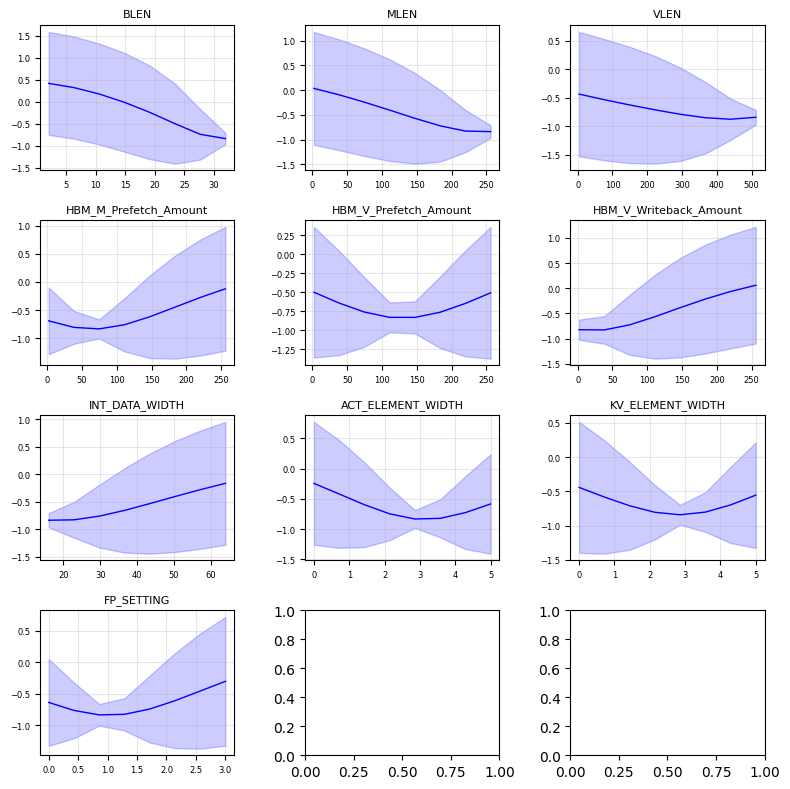

In [150]:
import matplotlib.pyplot as plt
import torch
import os

# Create output folder
os.makedirs("gp_slices", exist_ok=True)

def plot_all_gp_slices(model, base_point, n_dims=10):
    # Calculate grid layout (7x7 for 49 dimensions)
    cols = 3
    rows = 4
    fig, axes = plt.subplots(rows, cols, figsize=(8, 8))  # Large figure
    
    # Flatten axes for easy iteration
    axes = axes.ravel()
    
    for dim in range(n_dims):
        x_min = train_X[:, dim].min().item()
        x_max = train_X[:, dim].max().item()
        x_range = torch.linspace(x_min, x_max, 8)
        # Create test points for this dimension
        test_X = base_point.repeat(8, 1)
        test_X[:, dim] = x_range
        
        # Get posterior
        with torch.no_grad():
            posterior = model.posterior(test_X)
            mean = posterior.mean.squeeze()
            # print(mean)
            lower, upper = posterior.confidence_region()
        
        # Plot on the corresponding subplot
        ax = axes[dim]
        ax.plot(x_range.numpy(), mean.numpy(), 'b-', linewidth=1)
        ax.fill_between(x_range.numpy(), lower.numpy(), upper.numpy(), 
                       color='blue', alpha=0.2)
        
        # Format subplot
        ax.set_title(feature_order[dim], fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=6)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save and show
    save_path = "gp_slices/all_dims_accuracy.png"
    # plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # print(f"[INFO] Saved combined GP slices to: {save_path}")

# Find best point to use as base for slicing
best_idx = torch.argmin(train_Y)  # if minimizing
base_point = train_X[best_idx].clone().unsqueeze(0)

# Create the big combined plot
plot_all_gp_slices(model, base_point)

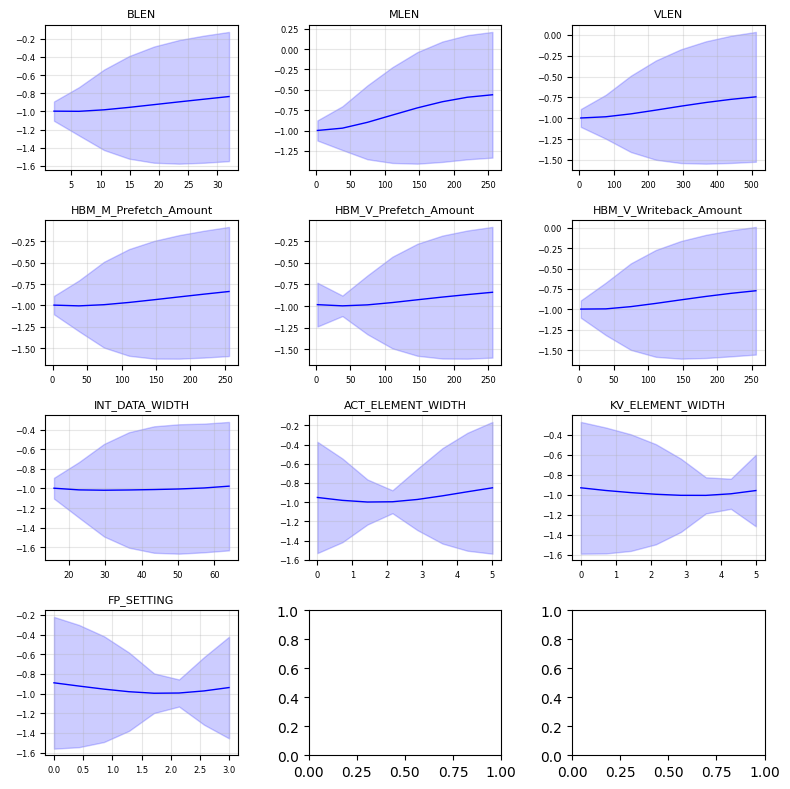

In [147]:
import matplotlib.pyplot as plt
import torch
import os

# Create output folder
os.makedirs("gp_slices", exist_ok=True)

def plot_all_gp_slices(model, base_point, n_dims=10):
    # Calculate grid layout (7x7 for 49 dimensions)
    cols = 3
    rows = 4
    fig, axes = plt.subplots(rows, cols, figsize=(8, 8))  # Large figure
    
    # Flatten axes for easy iteration
    axes = axes.ravel()
    
    for dim in range(n_dims):
        x_min = train_X[:, dim].min().item()
        x_max = train_X[:, dim].max().item()
        x_range = torch.linspace(x_min, x_max, 8)
        # Create test points for this dimension
        test_X = base_point.repeat(8, 1)
        test_X[:, dim] = x_range
        
        # Get posterior
        with torch.no_grad():
            posterior = model.posterior(test_X)
            mean = posterior.mean.squeeze()
            # print(mean)
            lower, upper = posterior.confidence_region()
        
        # Plot on the corresponding subplot
        ax = axes[dim]
        ax.plot(x_range.numpy(), mean.numpy(), 'b-', linewidth=1)
        ax.fill_between(x_range.numpy(), lower.numpy(), upper.numpy(), 
                       color='blue', alpha=0.2)
        
        # Format subplot
        ax.set_title(feature_order[dim], fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=6)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save and show
    save_path = "gp_slices/all_dims_accuracy.png"
    # plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # print(f"[INFO] Saved combined GP slices to: {save_path}")

# Find best point to use as base for slicing
best_idx = torch.argmin(train_Y)  # if minimizing
base_point = train_X[best_idx].clone().unsqueeze(0)

# Create the big combined plot
plot_all_gp_slices(model, base_point)

In [141]:
train_X

tensor([[  8.,  32.,   8.,  32.,   8.,   4.,  16.,   1.,   2.,   0.],
        [  2.,   2., 128.,   8., 128.,  64.,  64.,   2.,   4.,   3.],
        [  8.,  32., 256.,  32.,   8.,  16.,  16.,   4.,   2.,   3.],
        [  2.,   4.,  32., 128., 128.,  32.,  64.,   3.,   3.,   0.],
        [ 32.,  32., 128.,  64.,  64., 256.,  64.,   2.,   4.,   0.],
        [  4.,  16.,   4.,  16., 128.,  16.,  16.,   3.,   2.,   3.],
        [  4., 128.,  16.,   8.,   8., 256.,  64.,   0.,   1.,   2.],
        [ 16.,  16.,  32.,   4.,   8.,  16.,  32.,   4.,   3.,   1.],
        [  8.,  16.,  64.,  64.,  64.,  64.,  16.,   0.,   4.,   1.],
        [  4.,  16., 256.,   8.,  16.,   2.,  32.,   3.,   4.,   3.],
        [  4.,   4.,  16., 128., 128., 256.,  16.,   1.,   4.,   0.],
        [  2.,   2.,   4.,   2., 256., 256.,  32.,   2.,   0.,   0.],
        [  8.,   8., 128.,   8.,   2., 256.,  16.,   3.,   4.,   2.],
        [  2.,   4.,  32., 128.,   4.,  32.,  16.,   3.,   2.,   1.],
        [  8., 128.,

RuntimeError: A single best trial cannot be retrieved from a multi-objective study. Consider using Study.best_trials to retrieve a list containing the best trials.

In [88]:
t

FrozenTrial(number=1, state=1, values=[-0.2614628191639401, 1.0, -1.0], datetime_start=datetime.datetime(2025, 8, 15, 20, 56, 44, 50095), datetime_complete=datetime.datetime(2025, 8, 15, 21, 3, 6, 841668), params={'BLEN': 8, 'MLEN': 32, 'VLEN': 8, 'HBM_M_Prefetch_Amount': 32, 'HBM_V_Prefetch_Amount': 8, 'HBM_V_Writeback_Amount': 4, 'ACT_ELEMENT_WIDTH': 'MXFP_E4M3', 'KV_ELEMENT_WIDTH': 'MXFP_E5M2', 'FP_SETTING': 'FP_E4M7', 'INT_DATA_WIDTH': 16}, user_attrs={}, system_attrs={'NSGAIISampler:generation': 0}, intermediate_values={}, distributions={'BLEN': CategoricalDistribution(choices=(2, 4, 8, 16, 32)), 'MLEN': CategoricalDistribution(choices=(2, 4, 8, 16, 32, 64, 128, 256, 512)), 'VLEN': CategoricalDistribution(choices=(2, 4, 8, 16, 32, 64, 128, 256, 512, 1024)), 'HBM_M_Prefetch_Amount': CategoricalDistribution(choices=(2, 4, 8, 16, 32, 64, 128, 256)), 'HBM_V_Prefetch_Amount': CategoricalDistribution(choices=(2, 4, 8, 16, 32, 64, 128, 256)), 'HBM_V_Writeback_Amount': CategoricalDistribu

In [ ]:
t.params

{'BLEN': 8,
 'MLEN': 32,
 'VLEN': 8,
 'HBM_M_Prefetch_Amount': 32,
 'HBM_V_Prefetch_Amount': 8,
 'HBM_V_Writeback_Amount': 4,
 'ACT_ELEMENT_WIDTH': 'MXFP_E4M3',
 'KV_ELEMENT_WIDTH': 'MXFP_E5M2',
 'FP_SETTING': 'FP_E4M7',
 'INT_DATA_WIDTH': 16}

In [82]:
len(trials)

26